CO2 generation rate: 0.03581903922889569 mol/day
Cl2 generation rate: 0.004477379903611961 mol/day
H2 generation rate: 0.0223868995180598 mol/day


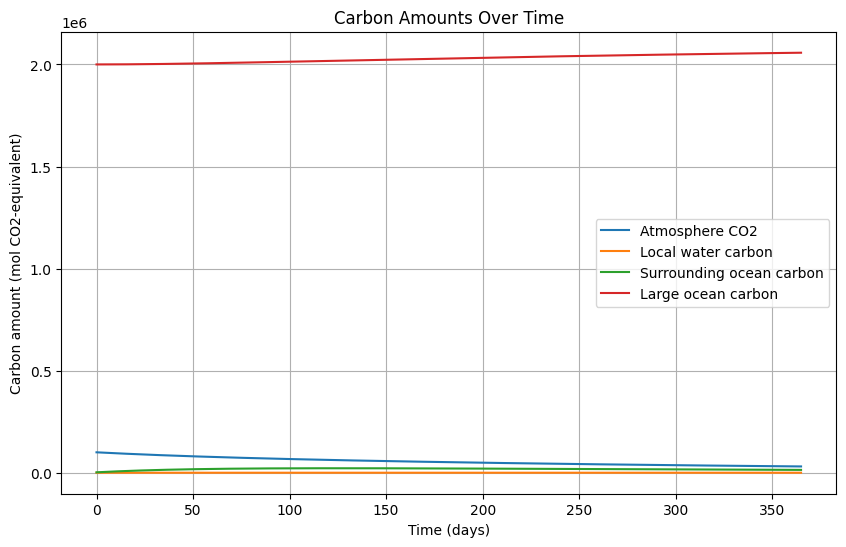

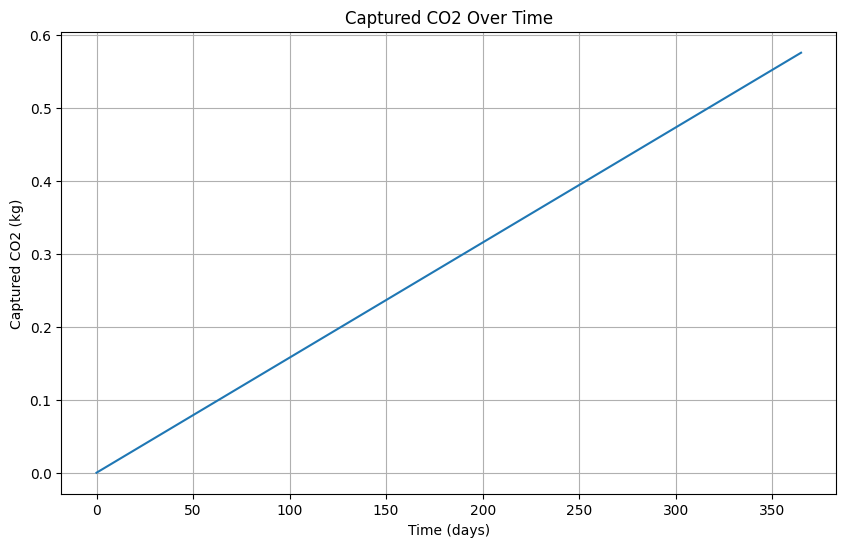

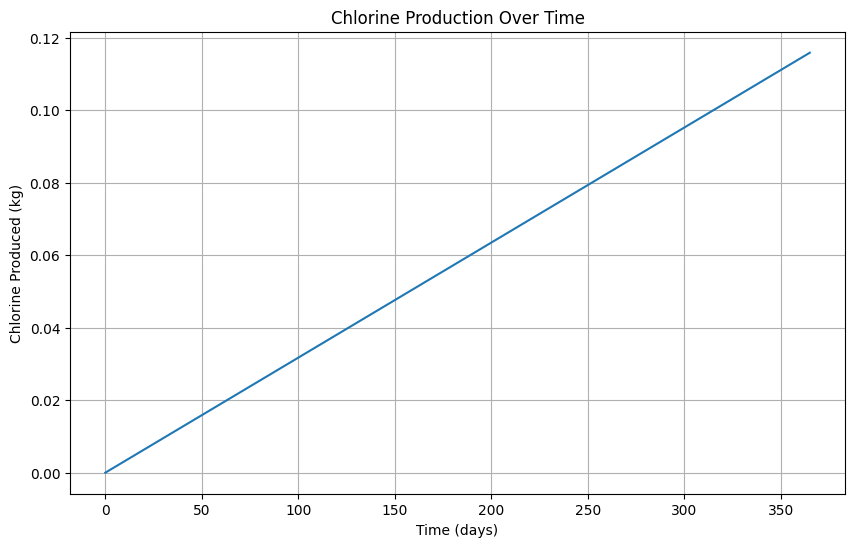

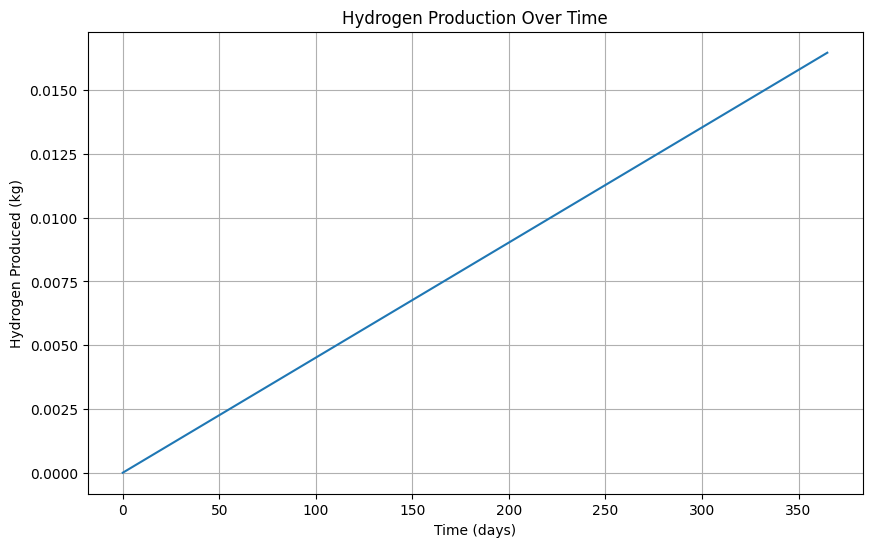

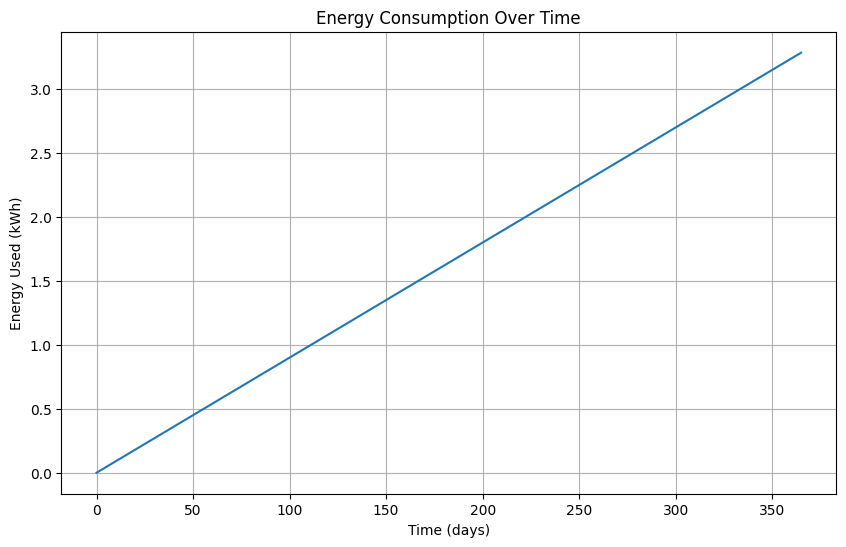

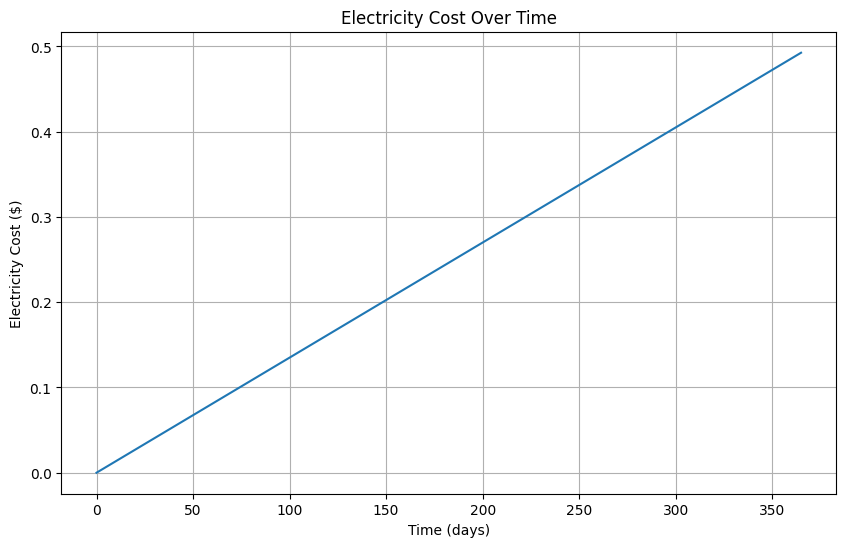

----- Final Results -----
Final captured CO2: 13.070367414623625 mol
Final captured CO2: 0.5752268699175858 kg
Final chlorine produced: 1.6337959268279532 mol
Final chlorine produced: 0.11583613121210189 kg
Final hydrogen produced: 8.168979634140289 mol
Final hydrogen produced: 0.016468662942426823 kg
Final energy used: 3.2841000000000764 kWh
Final electricity cost: $ 0.49261500000001146
Energy per kg CO2: 5.709225649473916 kWh/kg
Cost per kg CO2: $ 0.8563838474210874
Cost per metric ton CO2: $ 856.3838474210875


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Simulation settings
# ----------------------------

days = 365
dt_days = 0.1
steps = int(days / dt_days)
time = np.arange(steps) * dt_days
dt_seconds = dt_days * 24 * 60 * 60

# ----------------------------
# 2. Constants
# ----------------------------

F = 96485  # Faraday constant, C/mol e-

M_CO2 = 44.01  # g/mol
M_Cl2 = 70.90  # g/mol
M_H2 = 2.016   # g/mol

# ----------------------------
# 3. Water box volumes
# ----------------------------

V0 = 1           # m^3, local water near device
V1 = 1000        # m^3, surrounding ocean
V2 = 1_000_000   # m^3, large ocean reservoir

C_ocean_initial = 2  # mol/m^3 CO2-equivalent carbon

# ----------------------------
# 4. Initial carbon amounts
# ----------------------------

A = np.zeros(steps)         # atmosphere CO2, mol
W0 = np.zeros(steps)        # local water carbon, mol
W1 = np.zeros(steps)        # surrounding water carbon, mol
W2 = np.zeros(steps)        # large ocean carbon, mol
captured = np.zeros(steps)  # captured CO2, mol
chlorine = np.zeros(steps)  # produced Cl2, mol
hydrogen = np.zeros(steps)  # produced H2, mol
energy_kWh = np.zeros(steps)

A[0] = 100_000
W0[0] = C_ocean_initial * V0
W1[0] = C_ocean_initial * V1
W2[0] = C_ocean_initial * V2

# ----------------------------
# 5. Electrolysis settings
# ----------------------------

current = 0.05  # amps
voltage = 7.5  # volts

chlorine_fraction = 0.2
oxygen_fraction = 1 - chlorine_fraction

# Anode useful reaction:
# 2H2O -> O2 + 4H+ + 4e-
# 1 mol e- produces 1 mol H+
# HCO3- + H+ -> CO2 + H2O
# so 1 mol e- can produce up to 1 mol CO2, simplified

co2_rate_mol_per_second = oxygen_fraction * current / F

# Chlorine reaction:
# 2Cl- -> Cl2 + 2e-
chlorine_rate_mol_per_second = chlorine_fraction * current / (2 * F)

# Cathode reaction:
# 2H2O + 2e- -> H2 + 2OH-
hydrogen_rate_mol_per_second = current / (2 * F)

print("CO2 generation rate:", co2_rate_mol_per_second * 86400, "mol/day")
print("Cl2 generation rate:", chlorine_rate_mol_per_second * 86400, "mol/day")
print("H2 generation rate:", hydrogen_rate_mol_per_second * 86400, "mol/day")

# ----------------------------
# 6. Mixing / exchange constants
# ----------------------------

k01 = 0.08   # local <-> surrounding water, per day
k12 = 0.01   # surrounding <-> large ocean, per day
kAW = 0.005  # atmosphere <-> surrounding surface ocean, simplified per day

# ----------------------------
# 7. Simulation loop
# ----------------------------

for i in range(1, steps):
    A_prev = A[i-1]
    W0_prev = W0[i-1]
    W1_prev = W1[i-1]
    W2_prev = W2[i-1]
    C_prev = captured[i-1]
    Cl_prev = chlorine[i-1]
    H_prev = hydrogen[i-1]
    E_prev = energy_kWh[i-1]

    # Possible CO2 generated by acidifying bicarbonate
    possible_co2 = co2_rate_mol_per_second * dt_seconds

    # Cannot capture more carbon than exists in local water box
    co2_captured = min(possible_co2, W0_prev)

    # Chlorine and hydrogen produced
    cl2_produced = chlorine_rate_mol_per_second * dt_seconds
    h2_produced = hydrogen_rate_mol_per_second * dt_seconds

    # Mixing / diffusion-like exchange using concentration differences
    flow_10 = k01 * (W1_prev / V1 - W0_prev / V0) * V0 * dt_days
    flow_21 = k12 * (W2_prev / V2 - W1_prev / V1) * V1 * dt_days

    # Still simplified and not Henry's law yet
    flow_AW = kAW * (A_prev - W1_prev) * dt_days

    # Update carbon boxes
    W0[i] = W0_prev + flow_10 - co2_captured
    W1[i] = W1_prev - flow_10 + flow_21 + flow_AW
    W2[i] = W2_prev - flow_21
    A[i] = A_prev - flow_AW
    captured[i] = C_prev + co2_captured

    # Update gas products
    chlorine[i] = Cl_prev + cl2_produced
    hydrogen[i] = H_prev + h2_produced

    # Energy
    power_watts = current * voltage
    energy_kWh[i] = E_prev + power_watts * dt_seconds / 3_600_000

# ----------------------------
# 8. Unit conversions
# ----------------------------

captured_kg = captured * M_CO2 / 1000
chlorine_kg = chlorine * M_Cl2 / 1000
hydrogen_kg = hydrogen * M_H2 / 1000

electricity_price = 0.15  # dollars/kWh
cost = energy_kWh * electricity_price

# ----------------------------
# 9. Plots
# ----------------------------

plt.figure(figsize=(10, 6))
plt.plot(time, A, label="Atmosphere CO2")
plt.plot(time, W0, label="Local water carbon")
plt.plot(time, W1, label="Surrounding ocean carbon")
plt.plot(time, W2, label="Large ocean carbon")
plt.xlabel("Time (days)")
plt.ylabel("Carbon amount (mol CO2-equivalent)")
plt.title("Carbon Amounts Over Time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, captured_kg)
plt.xlabel("Time (days)")
plt.ylabel("Captured CO2 (kg)")
plt.title("Captured CO2 Over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, chlorine_kg)
plt.xlabel("Time (days)")
plt.ylabel("Chlorine Produced (kg)")
plt.title("Chlorine Production Over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, hydrogen_kg)
plt.xlabel("Time (days)")
plt.ylabel("Hydrogen Produced (kg)")
plt.title("Hydrogen Production Over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, energy_kWh)
plt.xlabel("Time (days)")
plt.ylabel("Energy Used (kWh)")
plt.title("Energy Consumption Over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time, cost)
plt.xlabel("Time (days)")
plt.ylabel("Electricity Cost ($)")
plt.title("Electricity Cost Over Time")
plt.grid(True)
plt.show()

# ----------------------------
# 10. Summary
# ----------------------------

print("----- Final Results -----")
print("Final captured CO2:", captured[-1], "mol")
print("Final captured CO2:", captured_kg[-1], "kg")

print("Final chlorine produced:", chlorine[-1], "mol")
print("Final chlorine produced:", chlorine_kg[-1], "kg")

print("Final hydrogen produced:", hydrogen[-1], "mol")
print("Final hydrogen produced:", hydrogen_kg[-1], "kg")

print("Final energy used:", energy_kWh[-1], "kWh")
print("Final electricity cost: $", cost[-1])

if captured_kg[-1] > 0:
    print("Energy per kg CO2:", energy_kWh[-1] / captured_kg[-1], "kWh/kg")
    print("Cost per kg CO2: $", cost[-1] / captured_kg[-1])
    print("Cost per metric ton CO2: $", cost[-1] / (captured_kg[-1] / 1000))